# Mixture-of-Gaussians Reservoir + Linear Readout via MMD

The reservoir distribution is a mixture of $K$ randomly placed Gaussians in $\mathbb{R}^D$.
We learn a linear readout $y = Ax + b$ to match a 2D target distribution,
minimizing MMD with Gaussian reproducing kernels.

Key parameters to explore:
- $D$: reservoir dimension
- $K$: number of Gaussian components in the reservoir
- Their relationship to the complexity of the target

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
from jax import jit
import optax
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew, kurtosis

print(f"JAX devices: {jax.devices()}")

JAX devices: [CpuDevice(id=0)]


## 1. Configuration

In [2]:
# --- Reservoir ---
D = 10                  # reservoir dimension
K = 4                  # number of Gaussian components in reservoir
MEAN_RADIUS = 5.0       # reservoir means drawn from Uniform(ball of this radius)
COV_SCALE = 0.5         # scale of random reservoir covariances

# --- Samples ---
N_RESERVOIR = 2048
N_TARGET = 2048
OUTPUT_DIM = 2          # target lives in R^2

# --- Training ---
LEARNING_RATE = 1e-2
LR_END_RATIO = 1e-2     # final LR = LEARNING_RATE * LR_END_RATIO
N_STEPS = 5000
BATCH_SIZE = 512//4
LOG_EVERY = 500

# --- MMD kernel bandwidths ---
SIGMAS = [0.1, 0.5, 1.0, 2.0, 5.0]

# --- Target: mixture of 2 Gaussians in 2D ---
TARGET_MEANS = jnp.array([[-3.0, -3.0],
                           [ 3.0,  3.0]])

TARGET_COVS = jnp.array([[[1.0, 0.5],
                           [0.5, 1.0]],
                          [[1.0, -0.3],
                           [-0.3, 0.5]]])

TARGET_WEIGHTS = jnp.array([0.4, 0.6])

## 2. Reservoir: random mixture of Gaussians in $\mathbb{R}^D$

In [3]:
def init_reservoir_mog(key, D, K, mean_radius, cov_scale):
    """Create a random mixture of K Gaussians in R^D.
    
    Means: uniform in a ball of given radius.
    Covariances: random PSD matrices via A A^T + small diagonal.
    Weights: uniform (1/K each).
    
    Returns dict with means (K, D), cholesky factors (K, D, D).
    """
    k1, k2, k3 = jr.split(key, 3)
    
    # random means: sample on sphere, then random radius
    directions = jr.normal(k1, (K, D))
    directions = directions / jnp.linalg.norm(directions, axis=1, keepdims=True)
    radii = jr.uniform(k2, (K, 1), minval=0.0, maxval=mean_radius)
    means = directions * radii  # (K, D)
    
    # random covariances via random factors
    # L_k = cov_scale * random_matrix / sqrt(D), then Sigma_k = L_k L_k^T + eps*I
    factors = jr.normal(k3, (K, D, D)) * cov_scale / jnp.sqrt(D)
    covs = jnp.einsum('kij,klj->kil', factors, factors)  # (K, D, D)
    covs = covs + 0.01 * jnp.eye(D)[None, :, :]  # regularize
    
    # precompute cholesky for sampling
    Ls = jnp.linalg.cholesky(covs)  # (K, D, D)
    
    return {'means': means, 'Ls': Ls, 'K': K, 'D': D}


def sample_reservoir(key, reservoir, n_samples):
    """Draw n_samples from the reservoir MoG (equal weights)."""
    means = reservoir['means']  # (K, D)
    Ls = reservoir['Ls']        # (K, D, D)
    K = reservoir['K']
    D = reservoir['D']
    
    k1, k2 = jr.split(key)
    
    # assign each sample to a component uniformly
    assignments = jr.choice(k1, K, shape=(n_samples,))
    
    # sample standard normals
    eps = jr.normal(k2, (n_samples, D))
    
    # transform per component
    samples = jnp.zeros((n_samples, D))
    for k in range(K):
        mask = (assignments == k)[:, None]
        component = eps @ Ls[k].T + means[k]
        samples = samples + mask * component
    
    return samples, assignments

## 3. Target distribution

In [4]:
def sample_target(key, n_samples, means, covs, weights):
    """Sample from target mixture of Gaussians."""
    K_t, M = means.shape
    k1, k2 = jr.split(key)
    assign = jr.choice(k1, K_t, shape=(n_samples,), p=weights)
    Ls = jnp.linalg.cholesky(covs)
    eps = jr.normal(k2, (n_samples, M))
    samples = jnp.zeros((n_samples, M))
    for k in range(K_t):
        mask = (assign == k)[:, None]
        samples = samples + mask * (eps @ Ls[k].T + means[k])
    return samples

## 4. MMD loss

In [5]:
def mmd_squared(P, Q, sigma):
    """Unbiased MMD^2 with Gaussian kernel."""
    n, m = P.shape[0], Q.shape[0]
    two_s2 = 2.0 * sigma ** 2
    
    def sq_dists(X, Y):
        return (jnp.sum(X**2, axis=1, keepdims=True)
                - 2.0 * X @ Y.T
                + jnp.sum(Y**2, axis=1))
    
    K_pp = jnp.exp(-sq_dists(P, P) / two_s2)
    K_qq = jnp.exp(-sq_dists(Q, Q) / two_s2)
    K_pq = jnp.exp(-sq_dists(P, Q) / two_s2)
    
    t_pp = (jnp.sum(K_pp) - jnp.trace(K_pp)) / (n * (n - 1))
    t_qq = (jnp.sum(K_qq) - jnp.trace(K_qq)) / (m * (m - 1))
    t_pq = jnp.sum(K_pq) / (n * m)
    
    return t_pp - 2.0 * t_pq + t_qq


def mmd_multi_bandwidth(P, Q, sigmas):
    return sum(mmd_squared(P, Q, s) for s in sigmas)

## 5. Linear readout and loss

In [6]:
def init_readout(key, output_dim, D):
    k1, _ = jr.split(key)
    A = jr.normal(k1, (output_dim, D)) * 0.01
    b = jnp.zeros(output_dim)
    return {'A': A, 'b': b}


def readout(params, X):
    """y = A x + b.  X: (n, D) -> (n, output_dim)."""
    return X @ params['A'].T + params['b']


def loss_fn(readout_params, reservoir_batch, target_batch, sigmas):
    Y = readout(readout_params, reservoir_batch)
    return mmd_multi_bandwidth(Y, target_batch, sigmas)

## 6. Generate samples

In [7]:
master_key = jr.PRNGKey(42)
k1, k2, k3, k4 = jr.split(master_key, 4)

# reservoir
reservoir = init_reservoir_mog(k1, D, K, MEAN_RADIUS, COV_SCALE)
reservoir_samples, reservoir_assignments = sample_reservoir(k2, reservoir, N_RESERVOIR)
print(f"Reservoir: {K} components in R^{D}")
print(f"Reservoir samples: {reservoir_samples.shape}")
print(f"  mean={float(jnp.mean(reservoir_samples)):.4f}, "
      f"std={float(jnp.std(reservoir_samples)):.4f}")

# target
target_samples = sample_target(k3, N_TARGET, TARGET_MEANS, TARGET_COVS, TARGET_WEIGHTS)
print(f"Target samples: {target_samples.shape}")

# readout
readout_params = init_readout(k4, OUTPUT_DIM, D)
print(f"A: {readout_params['A'].shape},  b: {readout_params['b'].shape}")

Reservoir: 4 components in R^10
Reservoir samples: (2048, 10)
  mean=-0.0249, std=0.7897
Target samples: (2048, 2)
A: (2, 10),  b: (2,)


## 7. Training

In [8]:
# cosine decay schedule
schedule = optax.cosine_decay_schedule(
    init_value=LEARNING_RATE,
    decay_steps=N_STEPS,
    alpha=LR_END_RATIO,
)

optimizer = optax.adam(schedule)
opt_state = optimizer.init(readout_params)


@jit
def train_step(params, opt_state, res_batch, tgt_batch):
    loss, grads = jax.value_and_grad(loss_fn)(params, res_batch, tgt_batch, SIGMAS)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss


losses = []
rng = jr.PRNGKey(0)

for step in range(N_STEPS):
    rng, k1, k2 = jr.split(rng, 3)
    idx_r = jr.choice(k1, N_RESERVOIR, shape=(BATCH_SIZE,), replace=False)
    idx_t = jr.choice(k2, N_TARGET,    shape=(BATCH_SIZE,), replace=False)
    
    readout_params, opt_state, loss = train_step(
        readout_params, opt_state,
        reservoir_samples[idx_r], target_samples[idx_t]
    )
    losses.append(float(loss))
    
    if step % LOG_EVERY == 0 or step == N_STEPS - 1:
        print(f"step {step:5d}  MMD² = {loss:.6f}")

print("Done.")

step     0  MMD² = 4.565326
step   500  MMD² = 0.199879
step  1000  MMD² = 0.110239
step  1500  MMD² = 0.108088
step  2000  MMD² = 0.117925
step  2500  MMD² = 0.204786
step  3000  MMD² = 0.139506
step  3500  MMD² = 0.107259
step  4000  MMD² = 0.114495
step  4500  MMD² = 0.057851
step  4999  MMD² = 0.145163
Done.


## 8. Visualization

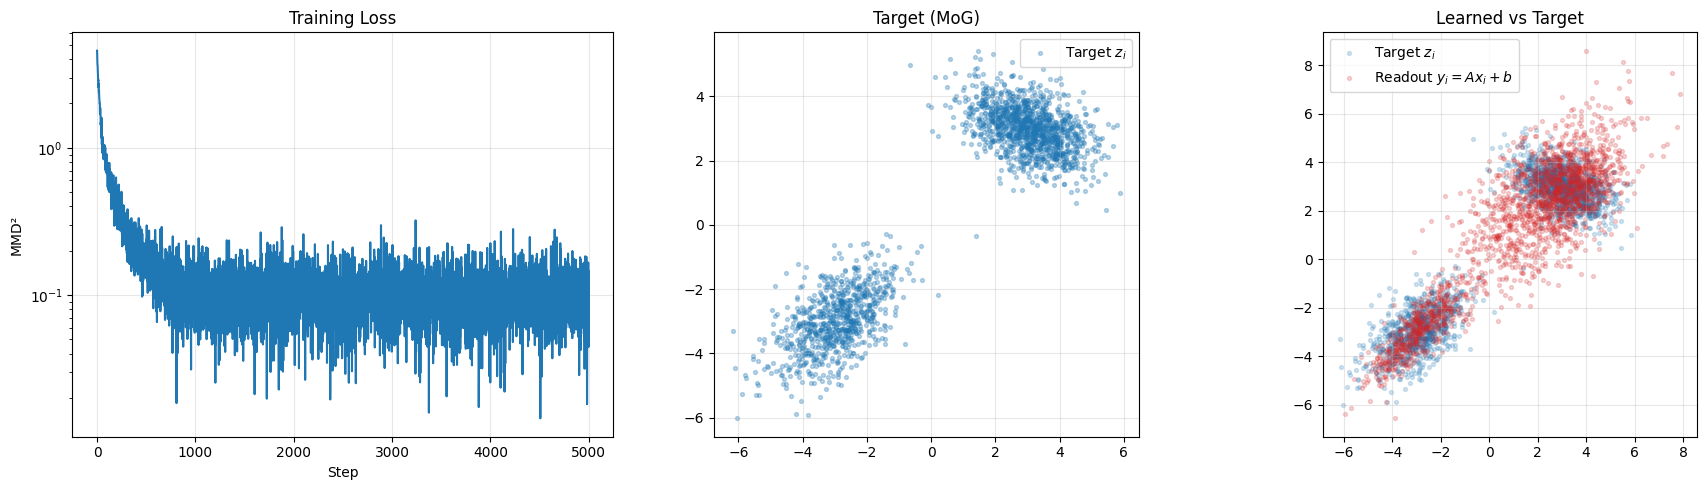

In [9]:
y_final = readout(readout_params, reservoir_samples)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# loss
axes[0].semilogy(losses)
axes[0].set_xlabel('Step'); axes[0].set_ylabel('MMD²')
axes[0].set_title('Training Loss'); axes[0].grid(True, alpha=0.3)

# target
axes[1].scatter(target_samples[:, 0], target_samples[:, 1],
                alpha=0.3, s=8, c='tab:blue', label='Target $z_i$')
axes[1].set_title('Target (MoG)'); axes[1].set_aspect('equal')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# overlay
axes[2].scatter(target_samples[:, 0], target_samples[:, 1],
                alpha=0.2, s=8, c='tab:blue', label='Target $z_i$')
axes[2].scatter(np.array(y_final[:, 0]), np.array(y_final[:, 1]),
                alpha=0.2, s=8, c='tab:red', label='Readout $y_i=Ax_i+b$')
axes[2].set_title('Learned vs Target'); axes[2].set_aspect('equal')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mog_reservoir_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

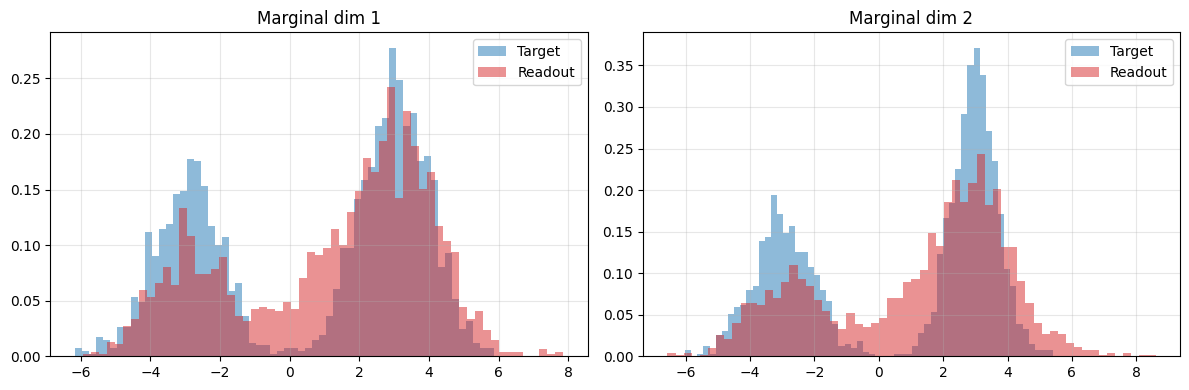

In [10]:
# marginal histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for d, ax in enumerate(axes):
    ax.hist(np.array(target_samples[:, d]), bins=60, density=True,
            alpha=0.5, color='tab:blue', label='Target')
    ax.hist(np.array(y_final[:, d]),        bins=60, density=True,
            alpha=0.5, color='tab:red',  label='Readout')
    ax.set_title(f'Marginal dim {d+1}'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mog_reservoir_marginals.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1070581/4284743709.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', K)


ModuleNotFoundError: No module named 'sklearn'

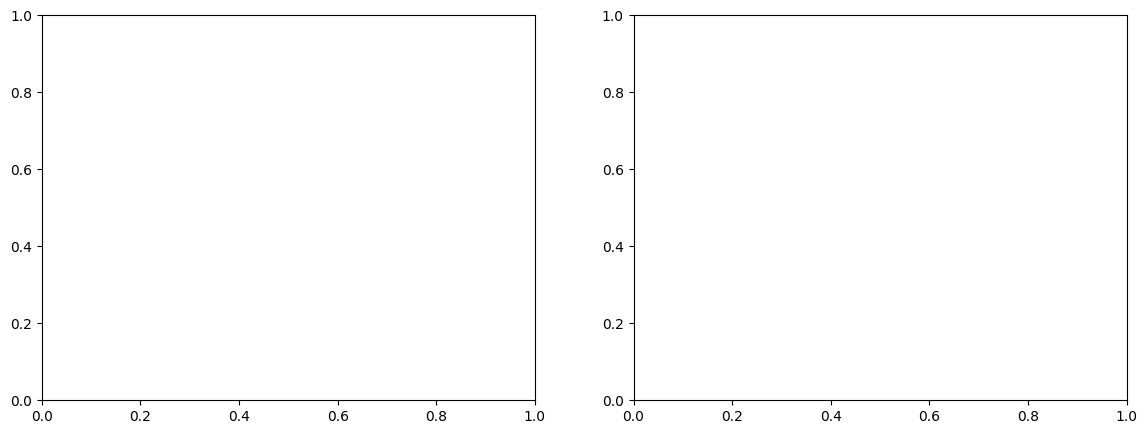

In [11]:
# color by reservoir component to see how readout routes them
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cmap = plt.cm.get_cmap('tab10', K)
colors = [cmap(a) for a in np.array(reservoir_assignments)]

# reservoir projected to first 2 PCs
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
res_2d = pca.fit_transform(np.array(reservoir_samples))
axes[0].scatter(res_2d[:, 0], res_2d[:, 1], c=colors, alpha=0.3, s=8)
axes[0].set_title(f'Reservoir (PCA to 2D), K={K} components')
axes[0].set_aspect('equal'); axes[0].grid(True, alpha=0.3)

# readout colored by component
axes[1].scatter(np.array(y_final[:, 0]), np.array(y_final[:, 1]),
                c=colors, alpha=0.3, s=8)
axes[1].set_title('Readout $y_i = Ax_i + b$, colored by reservoir component')
axes[1].set_aspect('equal'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mog_reservoir_components.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# moment comparison
z_np = np.array(target_samples)
y_np = np.array(y_final)

print(f"{'':22s} {'Target':>10s} {'Readout':>10s}")
print('-' * 44)
for d in range(OUTPUT_DIM):
    print(f"  Mean   dim {d+1}:      {z_np[:,d].mean():10.4f} {y_np[:,d].mean():10.4f}")
for d in range(OUTPUT_DIM):
    print(f"  Std    dim {d+1}:      {z_np[:,d].std():10.4f} {y_np[:,d].std():10.4f}")
for d in range(OUTPUT_DIM):
    print(f"  Skew   dim {d+1}:      {skew(z_np[:,d]):10.4f} {skew(y_np[:,d]):10.4f}")
for d in range(OUTPUT_DIM):
    print(f"  Kurt   dim {d+1}:      {kurtosis(z_np[:,d]):10.4f} {kurtosis(y_np[:,d]):10.4f}")
print(f"  Corr  (1,2):      {np.corrcoef(z_np.T)[0,1]:10.4f} {np.corrcoef(y_np.T)[0,1]:10.4f}")

## 9. Sweep: D and K

How does the reservoir dimension $D$ and number of components $K$ affect matching quality?

In [ ]:
def run_experiment(D, K, key, n_steps=3000):
    """Full pipeline for one (D, K) setting."""
    k1, k2, k3, k4 = jr.split(key, 4)
    
    res = init_reservoir_mog(k1, D, K, MEAN_RADIUS, COV_SCALE)
    rs, _ = sample_reservoir(k2, res, N_RESERVOIR)
    ro = init_readout(k3, OUTPUT_DIM, D)
    
    sched = optax.cosine_decay_schedule(
        init_value=LEARNING_RATE, decay_steps=n_steps, alpha=LR_END_RATIO
    )
    opt = optax.adam(sched)
    ost = opt.init(ro)
    
    @jit
    def step(ro, ost, rb, tb):
        l, g = jax.value_and_grad(loss_fn)(ro, rb, tb, SIGMAS)
        u, ost = opt.update(g, ost, ro)
        ro = optax.apply_updates(ro, u)
        return ro, ost, l
    
    rng = k4
    tail = []
    for s in range(n_steps):
        rng, rk1, rk2 = jr.split(rng, 3)
        rb = rs[jr.choice(rk1, N_RESERVOIR, shape=(BATCH_SIZE,), replace=False)]
        tb = target_samples[jr.choice(rk2, N_TARGET, shape=(BATCH_SIZE,), replace=False)]
        ro, ost, l = step(ro, ost, rb, tb)
        if s >= n_steps - 200:
            tail.append(float(l))
    
    return np.mean(tail)


Ds = [5, 10, 20, 50]
Ks = [2, 5, 10, 20, 50]
results = {}
sweep_key = jr.PRNGKey(77)

for d in Ds:
    for k in Ks:
        sweep_key, sk = jr.split(sweep_key)
        fl = run_experiment(d, k, sk)
        results[(d, k)] = fl
        print(f"D={d:3d}  K={k:3d}  =>  MMD² = {fl:.6f}")

print('Sweep done.')

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
for d in Ds:
    vals = [results[(d, k)] for k in Ks]
    ax.plot(Ks, vals, 'o-', label=f'D={d}')

ax.set_xlabel('K (number of reservoir components)')
ax.set_ylabel('Final MMD²')
ax.set_title('Effect of Reservoir Dimension D and Components K')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mog_reservoir_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Harder target: 5-component mixture

In [ ]:
# 5-component target to stress-test
TARGET5_MEANS = jnp.array([
    [-4.0, -4.0],
    [ 4.0,  4.0],
    [-4.0,  4.0],
    [ 4.0, -4.0],
    [ 0.0,  0.0],
])

TARGET5_COVS = jnp.stack([0.5 * jnp.eye(2)] * 5)
TARGET5_WEIGHTS = jnp.ones(5) / 5.0

target5 = sample_target(jr.PRNGKey(99), N_TARGET,
                        TARGET5_MEANS, TARGET5_COVS, TARGET5_WEIGHTS)

# run for a few (D, K) configs
configs = [(10, 5), (20, 10), (50, 20), (50, 50)]

fig, axes = plt.subplots(1, len(configs) + 1, figsize=(5 * (len(configs) + 1), 5))

axes[0].scatter(target5[:, 0], target5[:, 1], alpha=0.3, s=8, c='tab:blue')
axes[0].set_title('Target (5 modes)'); axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

for idx, (d, k) in enumerate(configs):
    ck1, ck2, ck3, ck4 = jr.split(jr.PRNGKey(idx * 100), 4)
    
    res = init_reservoir_mog(ck1, d, k, MEAN_RADIUS, COV_SCALE)
    rs, _ = sample_reservoir(ck2, res, N_RESERVOIR)
    ro = init_readout(ck3, OUTPUT_DIM, d)
    
    sched = optax.cosine_decay_schedule(
        init_value=LEARNING_RATE, decay_steps=N_STEPS, alpha=LR_END_RATIO
    )
    opt = optax.adam(sched)
    ost = opt.init(ro)
    
    @jit
    def step(ro, ost, rb, tb):
        l, g = jax.value_and_grad(loss_fn)(ro, rb, tb, SIGMAS)
        u, ost = opt.update(g, ost, ro)
        ro = optax.apply_updates(ro, u)
        return ro, ost, l
    
    rng = ck4
    for s in range(N_STEPS):
        rng, rk1, rk2 = jr.split(rng, 3)
        rb = rs[jr.choice(rk1, N_RESERVOIR, shape=(BATCH_SIZE,), replace=False)]
        tb = target5[jr.choice(rk2, N_TARGET, shape=(BATCH_SIZE,), replace=False)]
        ro, ost, l = step(ro, ost, rb, tb)
    
    y = readout(ro, rs)
    ax = axes[idx + 1]
    ax.scatter(target5[:, 0], target5[:, 1], alpha=0.15, s=8, c='tab:blue')
    ax.scatter(np.array(y[:, 0]), np.array(y[:, 1]), alpha=0.15, s=8, c='tab:red')
    ax.set_title(f'D={d}, K={k}  MMD²={float(l):.4f}')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mog_reservoir_5modes.png', dpi=150, bbox_inches='tight')
plt.show()